# **Decision Tree Regression**

Decision Tree Regression is a machine learning algorithm that predicts a continuous numeric value by learning a series of if-else rules that split the data based on the most important features.

A Decision Tree is like a flowchart or a game of 20 Questions:

* The model asks simple yes/no questions about the data

* Each question splits the data into smaller groups

* At the end, it gives a number as the final prediction


## **How it works (easy idea)**

Imagine predicting a house price:

Is the house in a good location?

Is the house big?

Does it have many rooms?

By answering these questions step by step, the model finally reaches a value

# **Parts of a Decision Tree**
1. **Root Node**

* This is the starting point of the tree.

* It contains all the data.

* The tree asks the first and most important question here.

Example:
“Is house size greater than 150 sqm?”

2. **Internal Nodes (Decision Nodes)**

* These are the middle points of the tree.

* Each node asks a new question.

Example questions:

“Income > 50,000?”

“Number of rooms ≥ 3?”

Depending on the answer (Yes or No), the data moves to the next step.

3. **Leaf Nodes**

* These are the end points of the tree.

* No more questions are asked here.

* The model gives its final prediction.

In regression, this is a number, usually the average of the values in that group.

Example: Predicted house price = ₦30,000,000

4. **Branches**

* Branches are the paths that connect the nodes.

* They show the result of each question:

Yes → go one way

No → go another way

They guide the data from the top of the tree to the final prediction.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn import tree

In [ ]:
df_dec = pd.read_csv('/content/drive/MyDrive/Datasets/housing.csv')

In [ ]:
df_dec.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df_dec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
# Drop missing values
df_dec = df_dec.dropna()

# Features and target
X = df_dec[['longitude', 'latitude', 'housing_median_age', 'total_rooms',
        'total_bedrooms', 'population', 'households', 'median_income']]

y = df_dec['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Create and train the Decision Tree Regressor
dt_regressor = DecisionTreeRegressor(

    max_depth=10,           # Limit depth to prevent overfitting
    min_samples_split=20,   # Minimum samples required to split a node
    min_samples_leaf=10,    # Minimum samples required at a leaf node
    random_state=42
)

dt_regressor.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, min_samples_leaf=10, min_samples_split=20,
                      random_state=42)

**Remember**

A Decision Tree Regressor works like a game of 20 Questions.
It keeps asking yes/no questions to narrow down the data until it can make a prediction.

Creating the model

**`dt_regressor = DecisionTreeRegressor()`**


This line creates a Decision Tree Regressor from sklearn.

Inside the parentheses are hyperparameters — these are settings that control how the tree behaves and how it asks questions.

**`max_depth = 10`**

This limits how deep the tree can go (how many levels of questions it can ask).

Example

**“Don’t go too deep asking questions!”**

* Each level is one yes/no question

* If the tree goes too deep, it can memorize the data, which is bad

* By setting max_depth = 10, we are telling the tree:

“You can only ask up to 10 questions before you must stop and give an answer.”

**This helps keep the model simple and general.**

**`min_samples_split = 20`**

A node must have at least 20 data points before it is allowed to split.

Example

“Only split a group if it’s big enough!”

A split means the tree wants to ask a question like:

“Is income greater than ₦300,000?”

We are telling the tree:

“Don’t ask a new question unless there are at least 20 houses in this group.”

**This prevents the tree from making decisions based on too little data.**

**`min_samples_leaf = 10`**

Each leaf node (final answer box) must contain at least 10 data points.

This means the model cannot create a final prediction from a very small group.

Example

“Each final answer group should have at least 10 houses.”

A leaf is the end of the tree

This is where the final prediction is made
**bold text**
We are telling the tree:

“Make sure every final prediction is based on at least 10 examples.”

This makes predictions more stable and reliable.

In [ ]:
# Make predictions for the tain dataset
y_pred_train = dt_regressor.predict(X_train)
print(y_pred_train)

[221870.29245283 102065.13409962 244037.13100437 ... 345400.
 261352.63157895 251872.72727273]


In [ ]:
# Create a DataFrame for actual vs predicted values on the train set
results_df = pd.DataFrame({'Actual': y_train, 'Predicted': y_pred_train})
display(results_df.head(10))

,Actual,Predicted
17727,227600.0,221870.292453
2057,110400.0,102065.134100
6453,248100.0,244037.131004
4619,305600.0,375100.250000
15266,214600.0,231400.897436
6823,227300.0,202709.318707
8384,177200.0,181845.454545
2758,84700.0,64100.000000
18143,451400.0,409121.714286
15621,500001.0,424580.400000


In [ ]:
# Make predictions for the test dataset
y_pred_test = dt_regressor.predict(X_test)
print(y_pred_test)

[215201.53030303 188709.375      202709.3187067  ...  79421.76470588
 113330.76923077 131809.5505618 ]


In [ ]:
# Create a DataFrame for actual vs predicted values on the test set
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_test})
display(results_df.head(10))

,Actual,Predicted
14416,245800.0,215201.530303
16383,137900.0,188709.375000
7731,218200.0,202709.318707
1410,220800.0,112925.352113
1335,170500.0,158175.342466
16260,75000.0,91215.862069
18011,269400.0,302928.607143
10086,228900.0,202709.318707
18294,500001.0,458230.200000
18733,80800.0,64023.865672


In [ ]:
# Calculate metrics
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print("Training R² Score:", round(train_r2, 4))
print("Test R² Score:", round(test_r2, 4))

print("Training MAE:", round(train_mae, 2))
print("Test MAE:", round(test_mae, 2))

Training R² Score: 0.8054
Test R² Score: 0.7312
Training MAE: 34361.28
Test MAE: 40685.62


In [ ]:
average_house_price = df_dec['median_house_value'].mean()
MAE_percentage_of_avg = (test_mae / average_house_price) * 100

print(round(MAE_percentage_of_avg, 2))

19.67


**Feature Importance**

Feature Importance tells us how much each input feature contributes to the model’s predictions.
It helps us understand which features the tree thinks are most useful.

**How it works in Decision Trees**

1. Tree splitting

While training, the tree keeps asking questions (splitting the data) based on different features.

2. Measuring usefulness

Each split is evaluated by how much it reduces prediction error (e.g., Mean Squared Error for regression).

3. Assigning importance

Features that help improve predictions more often get higher importance scores.

Features that rarely improve predictions get lower scores.



In [ ]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_regressor.feature_importances_
}).sort_values('importance', ascending=False)

display(feature_importance)

,feature,importance
7,median_income,0.597315
0,longitude,0.171375
1,latitude,0.149376
2,housing_median_age,0.052824
5,population,0.011115
6,households,0.006720
4,total_bedrooms,0.006472
3,total_rooms,0.004802


**`X.columns`**

* This gives the names of your features (like 'median_income', 'total_rooms', etc.)


**`dt_regressor.feature_importances_`**

* After training, the decision tree tells you how much each feature was used to make decisions.

**`sort_values('importance', ascending=False)`**

* Sorts the table from most to least important features.

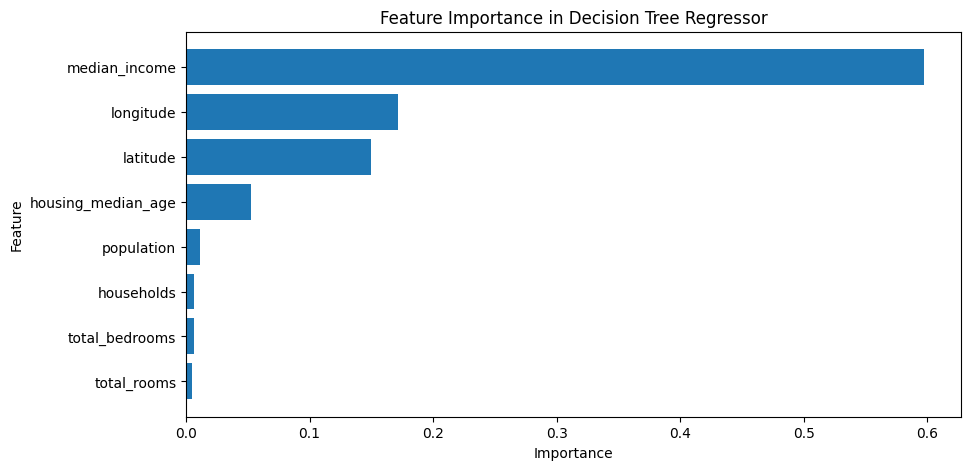

In [ ]:
sorted_importance = feature_importance.sort_values(by = 'importance', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(sorted_importance['feature'], sorted_importance['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Decision Tree Regressor')
plt.show()

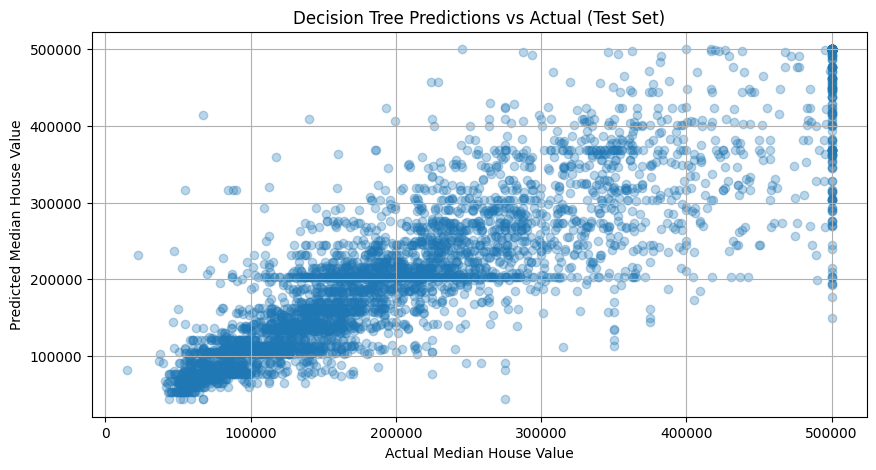

In [ ]:
# Plot actual vs predicted values for the testing set
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_test, alpha=0.3)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Decision Tree Predictions vs Actual (Test Set)")
plt.grid(True)
plt.show()

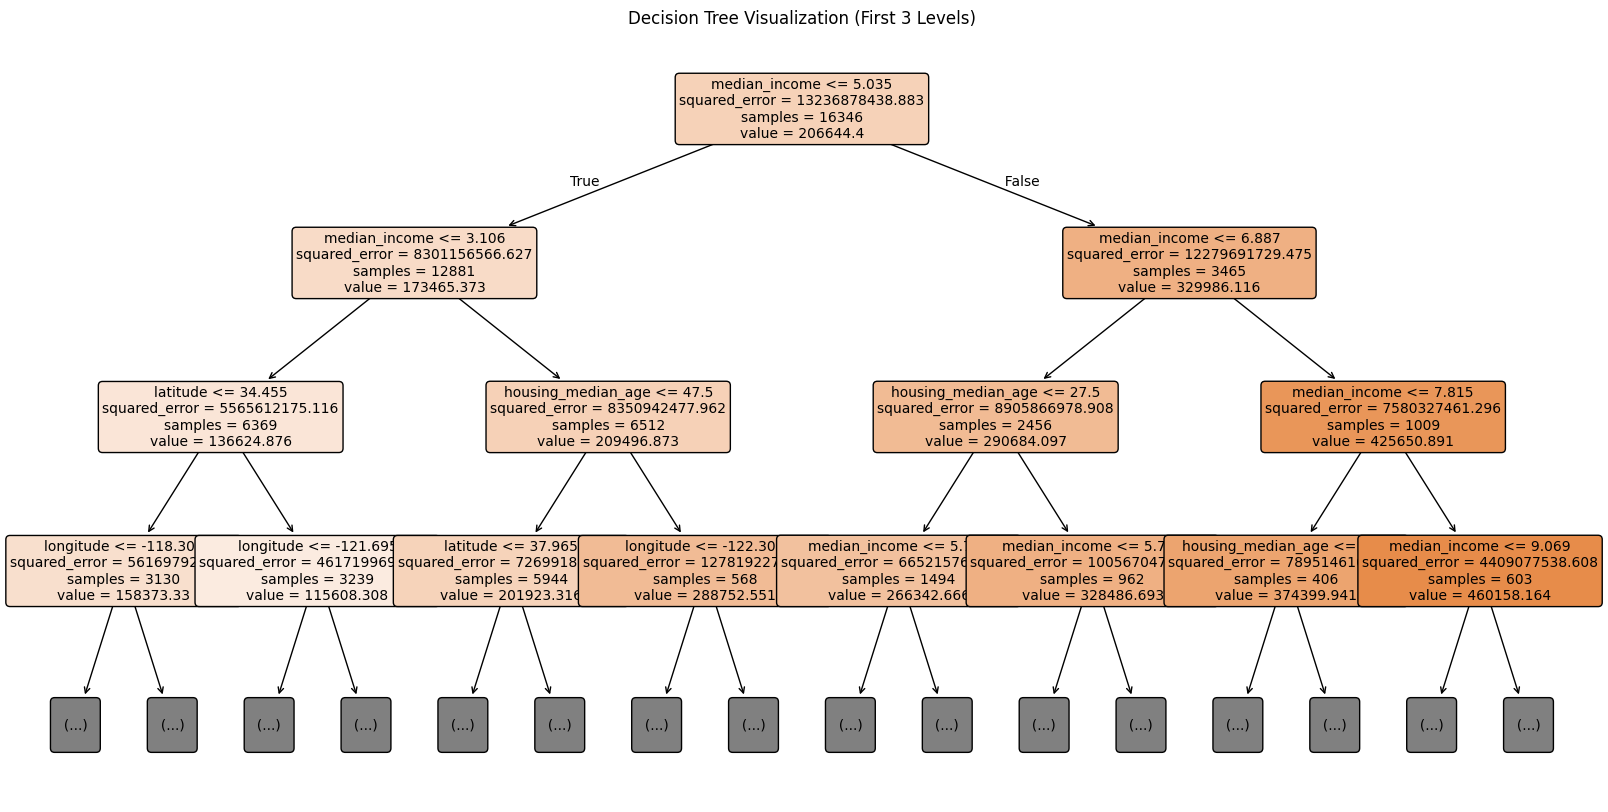

In [ ]:
# Visualize a small portion of the tree (first few levels)

plt.figure(figsize=(20, 10))
features = X.columns   #Define features using the DataFrame columns
tree.plot_tree(dt_regressor,
               feature_names=features,
               max_depth=3,  #Show only first 3 levels for readability
               filled=True,
               rounded=True,
               fontsize=10)
plt.title('Decision Tree Visualization (First 3 Levels)')
plt.show()



**`features = X.columns`**

Get the names of all features (columns) in the dataset.
These names will be used to label the nodes in the tree so you know which feature was split on

**`tree.plot_tree(...)`**

This function draws the decision tree diagram using the trained model.

**`dt_regressor`**

This is the trained Decision Tree Regressor model.

**max_depth=3**

Show only the first 3 levels of the tree (root + 2 more splits)

**filled=True**

* Fill the nodes with colors based on the output value (house price).

* The color intensity shows how high or low the predicted value is.

**rounded=True**

Round the corners of the boxes (nodes) for better appearance.

**fontsize=10**

* Sets the text size inside each box.

* Makes sure the feature names, values, and outputs are readable.

# **Random Forest Regression**

Random Forest Regression is like a forest of decision trees.
Instead of relying on just one tree, it builds many trees and combines their predictions to be more accurate and stable.

**How it works:**

1.  **Many Trees**: Instead of one tree, a Random Forest builds many individual decision trees.
2.  **Randomness**: Each tree is built using a random subset of the data (bootstrapping) and considers only a random subset of features for splitting at each node. This randomness helps to reduce overfitting.
3.  **Voting/Averaging**: For regression, the final prediction is the average of the predictions from all the individual trees. This averaging helps to smooth out individual tree errors and provides a more robust prediction.

### **Why Random Forest is often better than a single Decision Tree:**

*   **Reduced Overfitting**: Individual decision trees can easily overfit the training data. Random Forest, by combining many trees trained on different subsets of data and features, tends to generalize better to unseen data.
*   **Improved Accuracy**: The averaging process often leads to more accurate predictions than any single decision tree.
*   **Robustness**: It's less sensitive to noise or outliers in the data because multiple trees are involved.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Create and train the Random Forest Regressor
rf_regressor = RandomForestRegressor(
    n_estimators=100,      # Number of decision trees in the forest
    max_depth=10,          # Limit depth of each tree
    min_samples_split=20,  # Minimum samples required to split a node
    min_samples_leaf=10,   # Minimum samples required at a leaf node
    random_state=42,
    n_jobs=-1              # Use all available CPU cores
)

rf_regressor.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=10, min_samples_split=20,
                      n_jobs=-1, random_state=42)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### **Hyperparameters Explanation for Random Forest Regressor:**

*   **`n_estimators=100`**
    *   This is the number of individual decision trees the Random Forest will build. More trees generally lead to more stable and accurate predictions, but also increase computation time.
    *   **Analogy**: "Let's get 100 different experts (trees) to each give their opinion, and then we'll average their answers."

*   **`max_depth=10`**
    *   Similar to the Decision Tree, this limits how deep each individual tree in the forest can grow. It prevents any single tree from becoming too complex and overfitting.
    *   **Analogy**: "Each expert (tree) should only ask up to 10 questions before giving their prediction."

*   **`min_samples_split=20`**
    *   A node in any individual tree must have at least 20 data points to be considered for splitting. This helps prevent trees from creating branches for very small, potentially noisy, groups.
    *   **Analogy**: "An expert (tree) should only split a group if it contains at least 20 houses. Don't bother splitting tiny groups."

*   **`min_samples_leaf=10`**
    *   Each leaf node (the final prediction point) in any individual tree must contain at least 10 samples. This ensures that predictions are not based on very few data points, which can be unstable.
    *   **Analogy**: "Each final prediction given by an expert (tree) must be based on at least 10 houses."

*   **`random_state=42`**
    *   This ensures that the random processes (like selecting data subsets and features) are reproducible. If you run the code again with the same `random_state`, you'll get the same results.
    *   **Analogy**: "Let's make sure that when we pick random data and features, we do it the exact same way every time we run this experiment."

*   **`n_jobs=-1`**
    *   This tells the model to use all available CPU cores to train the trees in parallel, which can significantly speed up the training process for larger datasets and many trees.
    *   **Analogy**: "Let's use all our available helpers to build these trees at the same time to finish faster!"

In [ ]:
# Make predictions for the training dataset
y_pred_train_rf = rf_regressor.predict(X_train)

# Make predictions for the test dataset
y_pred_test_rf = rf_regressor.predict(X_test)

# Display some predictions
print("Random Forest Predictions (Training Set - first 10):")
print(y_pred_train_rf[:10])
print("\nRandom Forest Predictions (Test Set - first 10):")
print(y_pred_test_rf[:10])

Random Forest Predictions (Training Set - first 10):
[216534.96260459  97163.19512959 221245.70442977 286921.92884375
 244872.36226747 218501.23428459 179612.66683133  61708.14104986
 382927.01806245 430168.21898946]

Random Forest Predictions (Test Set - first 10):
[217587.68915278 152771.41918261 202025.04936587 128884.40126139
 153722.38744376  86701.72974158 284277.31518629 207726.00690327
 466491.15679752  69880.1837787 ]


In [ ]:
# Evaluate Random Forest model
rf_train_r2 = r2_score(y_train, y_pred_train_rf)
rf_test_r2 = r2_score(y_test, y_pred_test_rf)

rf_train_mae = mean_absolute_error(y_train, y_pred_train_rf)
rf_test_mae = mean_absolute_error(y_test, y_pred_test_rf)

print("Training R² Score:", round(rf_train_r2, 4))
print("Test R² Score:", round(rf_test_r2, 4))

print("Training MAE:", round(rf_train_mae, 2))
print("Test MAE:", round(rf_test_mae, 2))

Training R² Score: 0.8308
Test R² Score: 0.7791
Training MAE: 31872.57
Test MAE: 36640.07


In [ ]:
average_house_price = df_dec['median_house_value'].mean()
MAE_percentage_of_avg = (rf_test_mae / average_house_price) * 100

print(round(MAE_percentage_of_avg, 2))

17.71


In [ ]:
# Feature importance for Random Forest
rf_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_regressor.feature_importances_ #.feature_importances_ is a fxn that fetches the importance score
}).sort_values('importance', ascending=False)

display(rf_feature_importance)

,feature,importance
7,median_income,0.601485
0,longitude,0.161497
1,latitude,0.146397
2,housing_median_age,0.054576
5,population,0.012380
4,total_bedrooms,0.011139
3,total_rooms,0.006672
6,households,0.005855


### **Random Forest Feature Importance**

Just like with a single Decision Tree, Random Forest also provides a measure of feature importance. This tells us which input features were most influential in making the predictions across all the trees in the forest.

*   **How it works**: For each decision tree in the forest, it records how much each feature contributed to reducing impurity (or error) when that feature was used for a split. These contributions are then averaged across all trees to get a robust importance score for each feature.


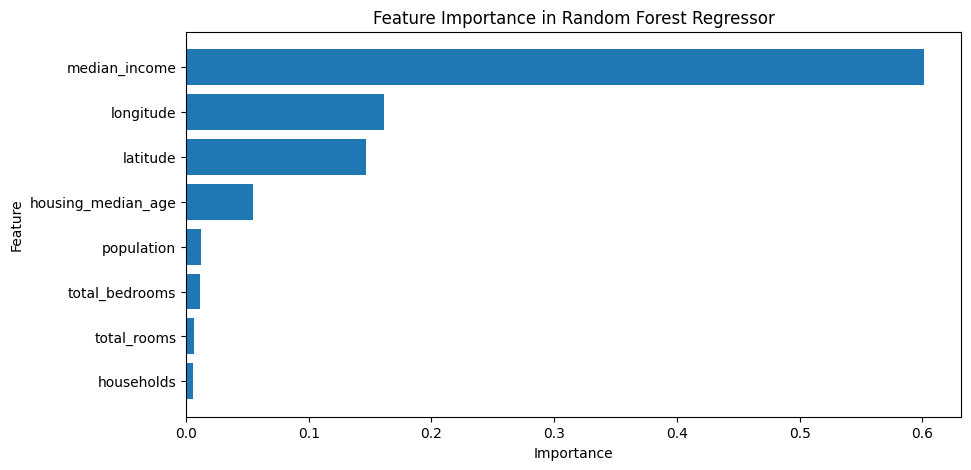

In [ ]:
sorted_importance_rf = rf_feature_importance.sort_values(by = 'importance', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(sorted_importance_rf['feature'], sorted_importance_rf['importance']) # we want to see what feature is most important. the model uses the feature with the least squared error
#as most important feature
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Random Forest Regressor')
plt.show()

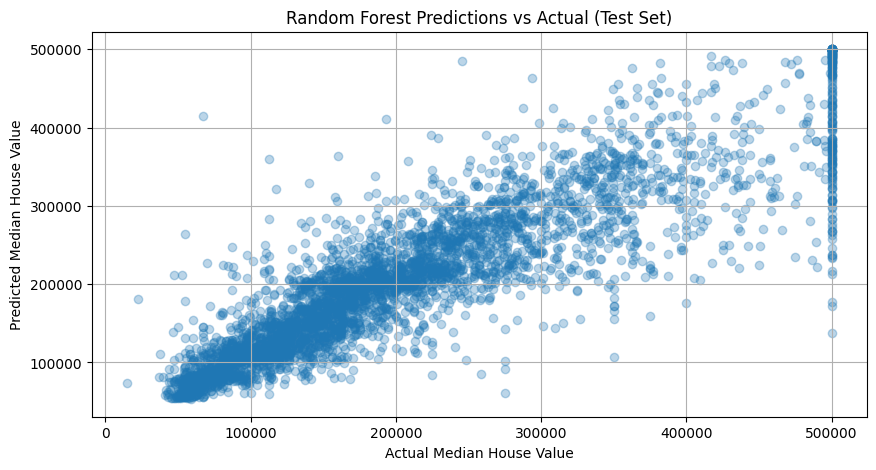

In [ ]:
# Plot actual vs predicted values for the testing set (Random Forest)
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_test_rf, alpha=0.3)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Random Forest Predictions vs Actual (Test Set)")
plt.grid(True)
plt.show()

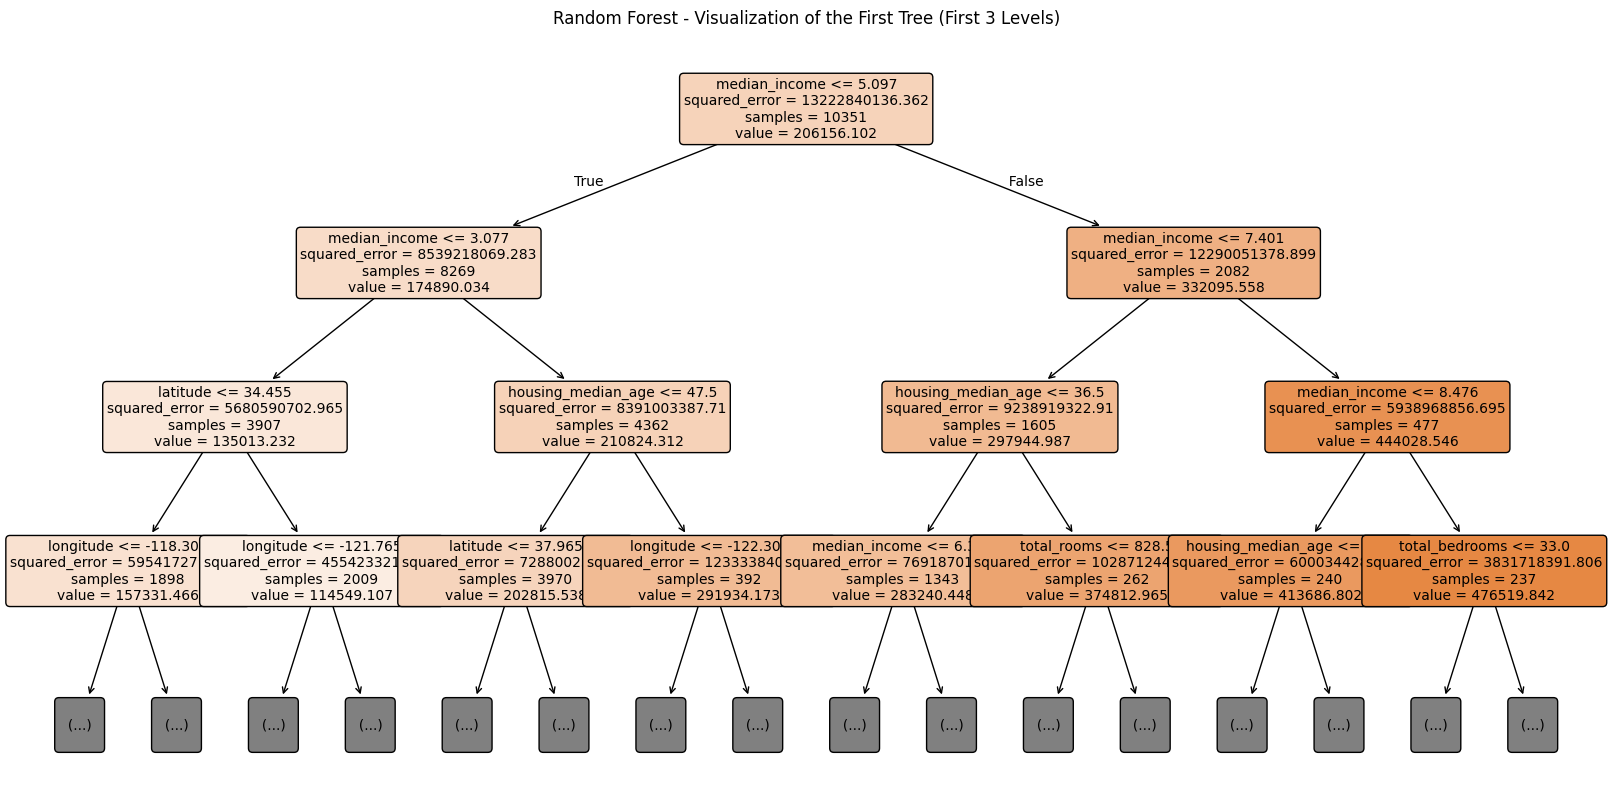

In [ ]:
plt.figure(figsize=(20, 10))
features = X.columns

# Access the first estimator (tree) from the Random Forest
# You can change the index ([0], [1], etc.) to view different trees
#forest tree, we cannot visualize all trees, we can only visualize one to visualize at a time

tree.plot_tree(rf_regressor.estimators_[2], # here we are plotting tree number 2 (3rd tree, rememeber 0,1,2). So the numbe ryou put in this square bracket
               #determines the tree you want to see. you can only see one tree at a time
               feature_names=features,
               max_depth=3, # the number of levels we want to see (level 0, 1, 2, 3 so these will be 4 splits as shown in the tree graph)
               filled=True,
               rounded=True,
               fontsize=10)
plt.title('Random Forest - Visualization of the Third Tree (First 3 Levels)')
plt.show()

#the model use the feature with the least squared error to start the tree so in this case, we use median income